In [1]:
!pip install numpy pandas torch scikit-learn

In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)

def generate_sample():
    volume_class = np.random.choice([5, 12, 25])
    thickness = np.random.uniform(2.0, 6.0)
    steel_grade = np.random.uniform(0.5, 1.0)
    corrosion = np.random.uniform(0.0, 0.7)

    pressure = np.random.uniform(1.0, 10.0)
    fill_factor = np.random.uniform(0.4, 1.0)

    temperature = np.random.uniform(10, 60)
    overpressure = np.random.uniform(0.5, 3.0)

    energy_index = pressure * volume_class * fill_factor * overpressure
    strength_index = (steel_grade * thickness) * (1 - corrosion + 0.1)

    failure_severity = energy_index / strength_index

    fragment_count = int(np.clip(failure_severity * 10 + np.random.normal(0, 5), 5, 500))
    spread_radius = float(np.clip(failure_severity * 2 + np.random.normal(0, 1), 1, 200))
    avg_velocity = float(np.clip(energy_index / (volume_class + 1) + np.random.normal(0, 1), 0, 100))
    dispersion_index = float(np.clip(failure_severity * np.random.uniform(0.8, 1.2), 0, 300))

    return [
        volume_class,
        thickness,
        steel_grade,
        corrosion,
        pressure,
        fill_factor,
        temperature,
        overpressure,
        fragment_count,
        spread_radius,
        avg_velocity,
        dispersion_index
    ]

def generate_dataset(n=10000):
    data = [generate_sample() for _ in range(n)]

    columns = [
        "volume_class",
        "thickness",
        "steel_grade",
        "corrosion",
        "pressure",
        "fill_factor",
        "temperature",
        "overpressure",
        "fragment_count",
        "spread_radius",
        "avg_velocity",
        "dispersion_index"
    ]

    return pd.DataFrame(data, columns=columns)

df = generate_dataset(20000)
df.to_csv("data.csv", index=False)

print(df.head())

   volume_class  thickness  steel_grade  corrosion  pressure  fill_factor  \
0            25   5.186172     0.591717   0.545784  6.371651     0.667500   
1            12   2.849356     0.590912   0.128383  3.738180     0.714854   
2            25   3.824280     0.892588   0.139772  5.628110     0.755449   
3            25   4.439987     0.916597   0.121355  4.519545     0.509342   
4            12   5.100531     0.969749   0.626379  6.381100     0.953125   

   temperature  overpressure  fragment_count  spread_radius  avg_velocity  \
0    14.998746      1.648122             500     200.000000      6.257369   
1    31.597251      1.228073             241      47.131803      3.343528   
2    12.322521      2.018862             500     131.886436      8.544586   
3    47.768071      1.562890             222      45.489548      2.065968   
4    14.424625      0.989957             307      61.382118      4.079234   

   dispersion_index  
0        112.186307  
1         22.070893  
2       

In [3]:
import pandas as pd

df = pd.read_csv("data.csv")

df.head()

,volume_class,thickness,steel_grade,corrosion,pressure,fill_factor,temperature,overpressure,fragment_count,spread_radius,avg_velocity,dispersion_index
0,25,5.186172,0.591717,0.545784,6.371651,0.667500,14.998746,1.648122,500,200.000000,6.257369,112.186307
1,12,2.849356,0.590912,0.128383,3.738180,0.714854,31.597251,1.228073,241,47.131803,3.343528,22.070893
2,25,3.824280,0.892588,0.139772,5.628110,0.755449,12.322521,2.018862,500,131.886436,8.544586,63.902223
3,25,4.439987,0.916597,0.121355,4.519545,0.509342,47.768071,1.562890,222,45.489548,2.065968,18.349482
4,12,5.100531,0.969749,0.626379,6.381100,0.953125,14.424625,0.989957,307,61.382118,4.079234,34.897128


In [11]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

In [12]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [13]:
import torch.nn as nn

class ExplosionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        return self.net(x)

model = ExplosionModel()

In [14]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [32]:
lambda_phys = 0.5

epochs = 50
lambda_phys = 0.1  # strength of physics constraint

for epoch in range(epochs):
    model.train()

    outputs = model(X_train)
    loss_data = criterion(outputs, y_train)

    # --- Physics constraint ---
    # Compare samples with slightly higher pressure
    X_high = X_train.clone()
    X_high[:, 4] = X_high[:, 4] * 1.2  # increase pressure slightly

    outputs_high = model(X_high)

    # Fragment count should not decrease
    phys_loss = torch.mean(torch.relu(outputs[:, 0] - outputs_high[:, 0]))

    # Total loss
    loss = loss_data + lambda_phys * phys_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}, PhysLoss: {phys_loss.item():.4f}")

Epoch 0, Loss: 0.0677, PhysLoss: 0.0475
Epoch 5, Loss: 0.0650, PhysLoss: 0.0480
Epoch 10, Loss: 0.0626, PhysLoss: 0.0482
Epoch 15, Loss: 0.0604, PhysLoss: 0.0485
Epoch 20, Loss: 0.0584, PhysLoss: 0.0491
Epoch 25, Loss: 0.0565, PhysLoss: 0.0496
Epoch 30, Loss: 0.0548, PhysLoss: 0.0501
Epoch 35, Loss: 0.0532, PhysLoss: 0.0505
Epoch 40, Loss: 0.0518, PhysLoss: 0.0509
Epoch 45, Loss: 0.0504, PhysLoss: 0.0514


In [33]:
model.eval()

with torch.no_grad():
    predictions = model(X_test)
    test_loss = criterion(predictions, y_test)

print("Test Loss:", test_loss.item())

Test Loss: 0.044415418058633804


In [34]:
sample = torch.tensor([[12, 4.0, 0.8, 0.2, 6.0, 0.7, 25, 1.5]], dtype=torch.float32)

model.eval()
with torch.no_grad():
    pred = model(sample)

print("Prediction:", pred)

Prediction: tensor([[ 6.6552,  7.7034,  6.6298, 10.2114]])


In [35]:
with torch.no_grad():
    pred_scaled = model(sample)

pred_real = scaler_y.inverse_transform(pred_scaled.numpy())

print("Real prediction:", pred_real)

Real prediction: [[1466.8649   592.4424    36.11915  652.04846]]


In [36]:
import numpy as np

preds = scaler_y.inverse_transform(predictions.numpy())
true = scaler_y.inverse_transform(y_test.numpy())

mae = np.mean(np.abs(preds - true))

print("Mean Absolute Error:", mae)

Mean Absolute Error: 11.16456


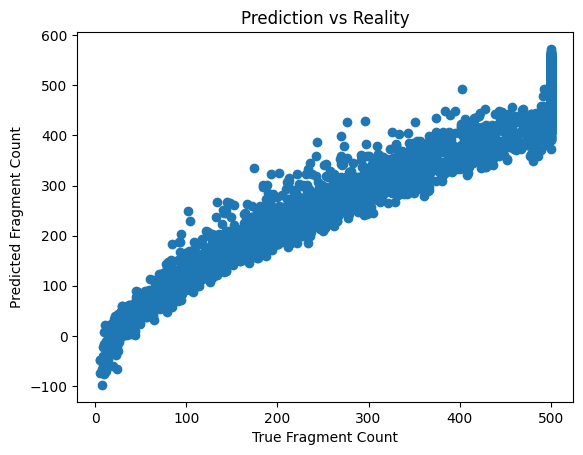

In [37]:
import matplotlib.pyplot as plt

plt.scatter(true[:,0], preds[:,0])
plt.xlabel("True Fragment Count")
plt.ylabel("Predicted Fragment Count")
plt.title("Prediction vs Reality")
plt.show()

In [38]:
torch.save(model.state_dict(), "model.pth")

In [51]:
def predict(input_data):
    model.eval()

    cols = [
        "volume_class",
        "thickness",
        "steel_grade",
        "corrosion",
        "pressure",
        "fill_factor",
        "temperature",
        "overpressure"
    ]

    import pandas as pd
    x_df = pd.DataFrame([input_data], columns=cols)
    x = scaler_X.transform(x_df)
    x = torch.tensor(x, dtype=torch.float32)

    with torch.no_grad():
        pred = model(x)

    return scaler_y.inverse_transform(pred.numpy())

# Example input
print(predict([12, 4.0, 0.8, 0.2, 6.0, 0.7, 25, 1.5]))

[[242.50728    62.95947     5.1849036  30.606901 ]]


In [57]:
import matplotlib.pyplot as plt
import numpy as np

model.eval()

with torch.no_grad():
    sample = X_test[:200]
    preds = model(sample)

preds = preds.numpy()

spread_radius = preds[:, 1]

density_factor = np.random.exponential(scale=1.0, size=len(preds))
base_radius = preds[:, 1]

density_factor = np.random.exponential(scale=1.0, size=len(preds))
spread_radius = base_radius * density_factor

zone_split = np.percentile(spread_radius, [33, 66])

core_mask = spread_radius <= zone_split[0]
mid_mask = (spread_radius > zone_split[0]) & (spread_radius <= zone_split[1])
outer_mask = spread_radius > zone_split[1]

In [61]:
base_angle = np.linspace(0, 2*np.pi, len(spread_radius))

pressure = X_test[:len(spread_radius), 4].numpy()
steel = X_test[:len(spread_radius), 2].numpy()
corrosion = X_test[:len(spread_radius), 3].numpy()

drift = (pressure - pressure.mean()) * 0.3
noise = np.random.normal(0, 0.2, len(spread_radius))

material_factor = (1 - steel) + corrosion

angles = base_angle + drift + noise + material_factor * 0.5

x = spread_radius * np.cos(angles)
y = spread_radius * np.sin(angles)

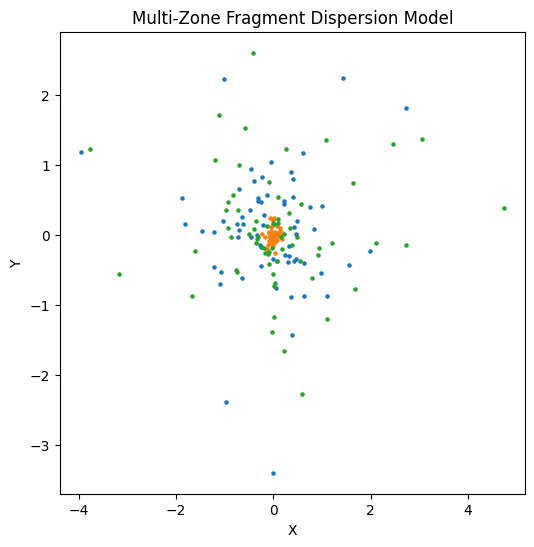

In [62]:
plt.figure(figsize=(6,6))

# Core zone
plt.scatter(
    (spread_radius[core_mask] * np.cos(angles[core_mask])),
    (spread_radius[core_mask] * np.sin(angles[core_mask])),
    s=5
)

# Mid zone
plt.scatter(
    (spread_radius[mid_mask] * np.cos(angles[mid_mask])),
    (spread_radius[mid_mask] * np.sin(angles[mid_mask])),
    s=5
)

# Outer zone
plt.scatter(
    (spread_radius[outer_mask] * np.cos(angles[outer_mask])),
    (spread_radius[outer_mask] * np.sin(angles[outer_mask])),
    s=5
)

plt.title("Multi-Zone Fragment Dispersion Model")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [63]:
import numpy as np

with torch.no_grad():
    preds = model(X_test).numpy()

errors = np.abs(preds - y_test.numpy())

confidence = 1 / (1 + np.mean(errors, axis=1))

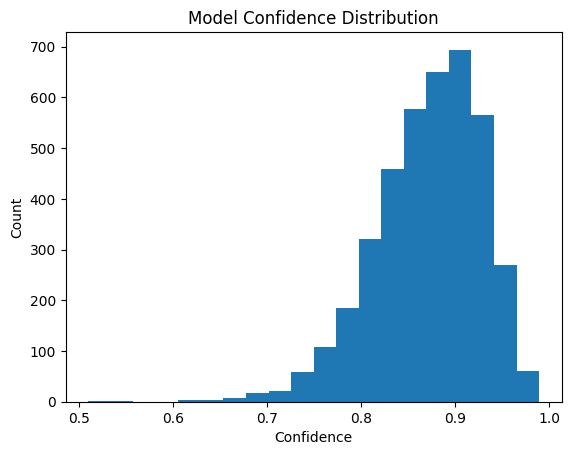

In [64]:
import matplotlib.pyplot as plt

plt.hist(confidence, bins=20)
plt.title("Model Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.show()

In [65]:
print("Average Confidence:", np.mean(confidence))

Average Confidence: 0.8713916


In [67]:
def run_demo(input_data):
    model.eval()

    cols = [
        "volume_class",
        "thickness",
        "steel_grade",
        "corrosion",
        "pressure",
        "fill_factor",
        "temperature",
        "overpressure"
    ]

    import pandas as pd
    x_df = pd.DataFrame([input_data], columns=cols)
    x_scaled = scaler_X.transform(x_df)
    x_tensor = torch.tensor(x_scaled, dtype=torch.float32)

    with torch.no_grad():
        pred_scaled = model(x_tensor).numpy()

    pred = scaler_y.inverse_transform(pred_scaled)

    # confidence approximation
    train_preds = model(X_train).detach().numpy()
    train_errors = np.mean(np.abs(train_preds - y_train.numpy()), axis=1)
    confidence = 1 / (1 + np.mean(train_errors))

    return pred, confidence

In [68]:
result, conf = run_demo([12, 4.0, 0.8, 0.2, 6.0, 0.7, 25, 1.5])

print("Prediction:", result)
print("Confidence:", conf)

Prediction: [[242.50728    62.95947     5.1849036  30.606901 ]]
Confidence: 0.8686593


In [69]:
torch.save(model.state_dict(), "model.pth")